
<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [62]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

# **Loading the dataset**

In [24]:
import pandas as pd

easyvisa_df = pd.read_csv('/content/EasyVisa.csv')
df = easyvisa_df.copy()

In [25]:
display(df.shape)

(25480, 12)

# **Overview of the Dataset**

## Observations

In [26]:
display(df.head())

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [27]:
display(df.tail())

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [28]:
display(df.shape)

(25480, 12)

In [29]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


None

- There are a total of 12 columns and 25480 observations in the dataset
- 9 columns are of object data type, 2 columns are of int data type, 1 column is of float data type.

## Sanity checks

In [30]:
# let's check for duplicate values in the data
df.duplicated().sum()

np.int64(0)

- There are no duplicate records

In [31]:
# Checking for the null value in the dataset
df.isna().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


- There are no null values in the dataset.

In [32]:
# unique values in each column
df.nunique()

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


In [33]:
# drop case_Id column as it is unique identifier and has all unique values
df.drop('case_id', axis=1, inplace=True)

In [34]:
# display data frame information after dropping case_Id column
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  object 
 2   has_job_experience     25480 non-null  object 
 3   requires_job_training  25480 non-null  object 
 4   no_of_employees        25480 non-null  int64  
 5   yr_of_estab            25480 non-null  int64  
 6   region_of_employment   25480 non-null  object 
 7   prevailing_wage        25480 non-null  float64
 8   unit_of_wage           25480 non-null  object 
 9   full_time_position     25480 non-null  object 
 10  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


None

In [35]:
# statistical summary of the numerical columns in the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


Observations from the statistical summary:
- `no_of_employees`: Minimum value is -26, which is invalid for the number of employees and needs to be addressed. The data is highly skewed with a very high maximum value (602069), indicating potential outliers.
- `yr_of_estab`: The years of establishment range from 1800 to 2016, which are plausible values.
- `prevailing_wage`: The minimum wage is 2.137, which appears extremely low and might be an outlier or an issue with wage units (e.g., hourly vs. yearly wages) that needs further investigation. The wages have a wide range, as indicated by the high standard deviation compared to the mean.


**Checking the value count for each category of categorical variables**

In [36]:
# Making a list of all categorical variables
cat_col = [
    "continent",
    "education_of_employee",
    "has_job_experience",
    "requires_job_training",
    "region_of_employment",
    "unit_of_wage",
    "full_time_position",
    "case_status",
]

# Printing number of count of each unique value in each column
for column in cat_col:
    print(df[column].value_counts())
    print("-" * 40)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
----------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
----------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
----------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
----------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
----------------------------------------
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64
----------------------------------------
full_time_position
Y    22773
N     2707
Name: count, dtype: int64
--------

Observations from the value counts of categorical variables:
- `continent`**: Asia has the highest number of applicants, followed by Europe and North America. Oceania has the least.
- `education_of_employee`**: The majority of applicants have a Bachelor's or Master's degree, with fewer having a High School education or a Doctorate.
- `has_job_experience`**: More applicants have job experience ('Y') than not ('N').
- `requires_job_training`**: The vast majority of applicants do not require job training ('N').
- `region_of_employment`**: Northeast and South regions of employment have the highest counts, while Island has the lowest.
- `unit_of_wage`**: The most common unit of wage is 'Year', significantly higher than 'Hour', 'Week', or 'Month'. This is an important observation, as the `prevailing_wage` needs to be considered in conjunction with this unit.
- `full_time_position`**: Most positions are full-time ('Y').
- `case_status`**: There are more 'Certified' visa applications than 'Denied' applications, indicating a class imbalance that might need to be addressed during model building.

In [37]:
# Map the target variable `case_status` to numerical values
df['case_status'] = df['case_status'].map({'Certified': 1, 'Denied': 0})
display(df['case_status'].value_counts())

,count
case_status,
1,17018
0,8462


In [38]:
# Function to convert wages to yearly based on unit
def convert_wage_to_yearly(row):
    if row['unit_of_wage'] == 'Hour':
        return row['prevailing_wage'] * 2080  # 40 hours/week * 52 weeks/year
    elif row['unit_of_wage'] == 'Week':
        return row['prevailing_wage'] * 52
    elif row['unit_of_wage'] == 'Month':
        return row['prevailing_wage'] * 12
    else:  # Year
        return row['prevailing_wage']

# Apply the conversion
df['prevailing_wage'] = df.apply(convert_wage_to_yearly, axis=1)

# Drop the 'unit_of_wage' column as it's no longer needed
df.drop('unit_of_wage', axis=1, inplace=True)
display(df.head())

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,1231782.032,Y,0
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Y,1
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Y,0
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Y,0
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Y,1


In [39]:
# Identify remaining categorical columns for one-hot encoding
categorical_cols_to_encode = [
    'continent',
    'education_of_employee',
    'has_job_experience',
    'requires_job_training',
    'region_of_employment',
    'full_time_position'
]

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

display(df.head())

,no_of_employees,yr_of_estab,prevailing_wage,case_status,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,full_time_position_Y
0,14513,2007,1231782.032,0,True,False,False,False,False,False,True,False,False,False,False,False,False,True,True
1,2412,2002,83425.650,1,True,False,False,False,False,False,False,True,True,False,False,True,False,False,True
2,44444,2008,122996.860,0,True,False,False,False,False,False,False,False,False,True,False,False,False,True,True
3,98,1897,83434.030,0,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,1082,2005,149907.390,1,False,False,False,False,False,False,False,True,True,False,False,False,True,False,True


### Observations from Univariate Analysis

**Numerical Columns:**

-   **`no_of_employees`**: The distribution is highly skewed to the right, indicating that most companies have a relatively small number of employees, with a few large companies acting as outliers. The minimum value of -26 is an anomaly and needs to be addressed (e.g., set to 0 or treated as missing). The presence of a large number of outliers on the higher end suggests a need for robust scaling or transformation if used in models sensitive to such distributions.
-   **`yr_of_estab`**: The distribution appears relatively spread out, with a peak around recent years (2000s) but also a significant number of older establishments. There are no apparent extreme outliers.
-   **`prevailing_wage`**: The distribution is right-skewed, indicating that most applicants have lower prevailing wages, while a smaller number have significantly higher wages. The minimum values, even after conversion to yearly wages, are still very low in some cases, which might warrant further investigation as potential outliers or data entry errors (e.g., initial hourly wages being extremely low). The large spread suggests a wide range of salaries, and potential outliers exist on the higher end.

**Target Variable:**

-   **`case_status`**: (Encoded as 0 for Denied, 1 for Certified). The histogram/boxplot would visually confirm the class imbalance noted earlier, with more applications being certified than denied.

**Categorical Columns (after One-Hot Encoding):**

-   The one-hot encoded columns (e.g., `continent_Europe`, `education_of_employee_Master's`, `has_job_experience_Y`, `requires_job_training_Y`, `region_of_employment_South`, `full_time_position_Y`) now represent binary features. Their distributions typically show the proportion of each category. For example:
    -   Columns like `continent_Asia` would likely show a high count for '1' (Asia) compared to '0' (not Asia), reflecting the dominance of Asian applicants.
    -   `has_job_experience_Y` would show a higher count for '1' (has job experience) than '0' (does not have).
    -   `requires_job_training_Y` would show a much higher count for '0' (does not require training) than '1' (requires training).
    -   `full_time_position_Y` would indicate that most positions are full-time.

These binary columns will be useful as direct input features for modeling, representing the presence or absence of a specific characteristic.

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

### Univariate analysis

In [40]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [41]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

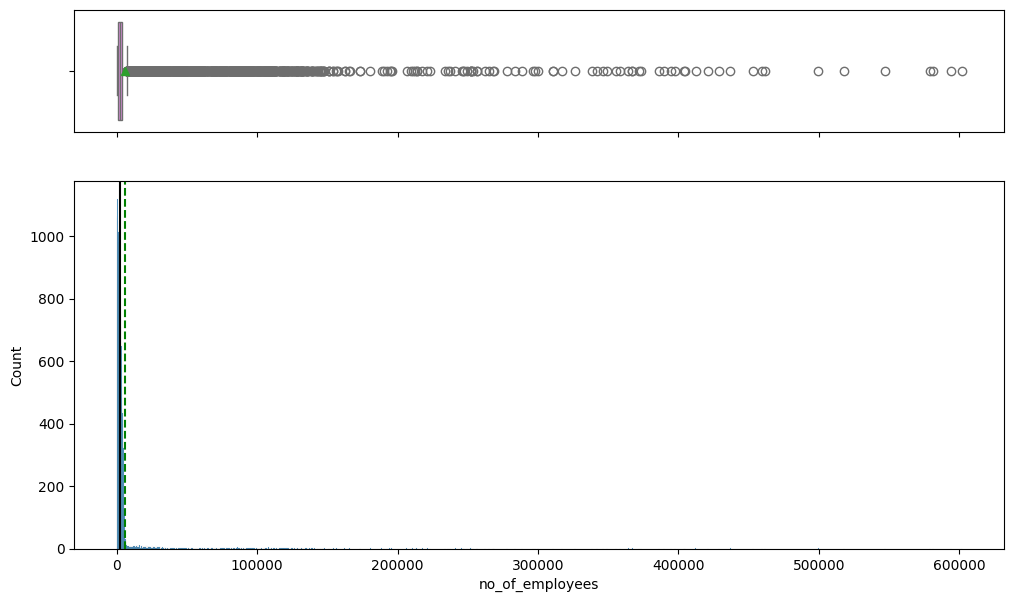

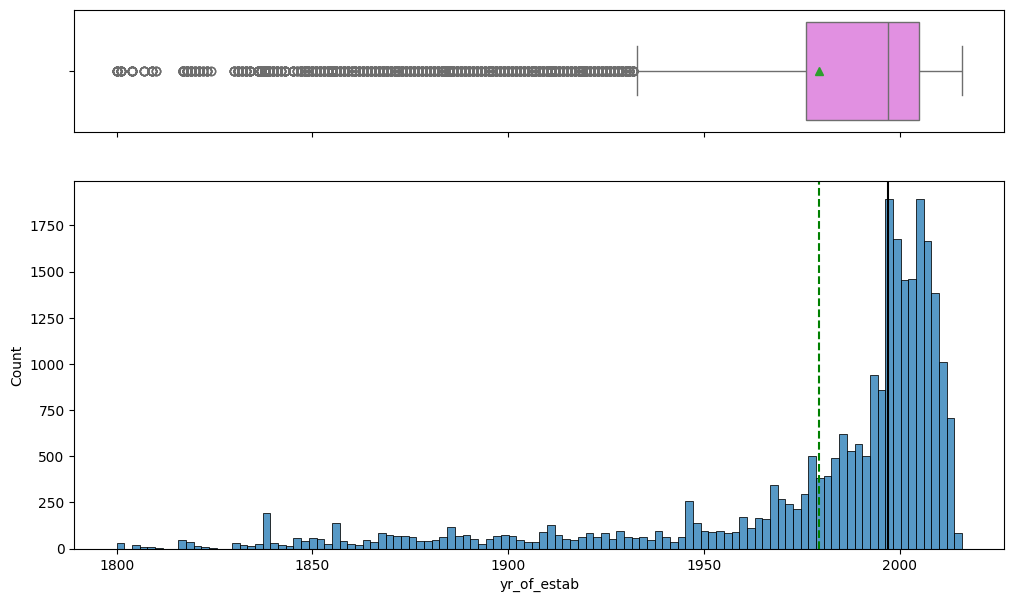

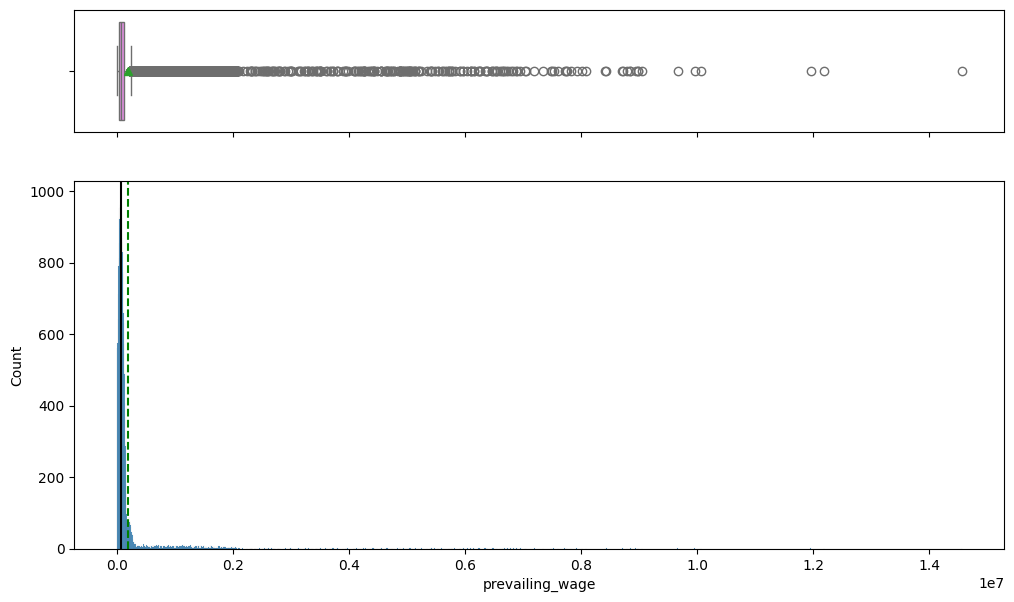

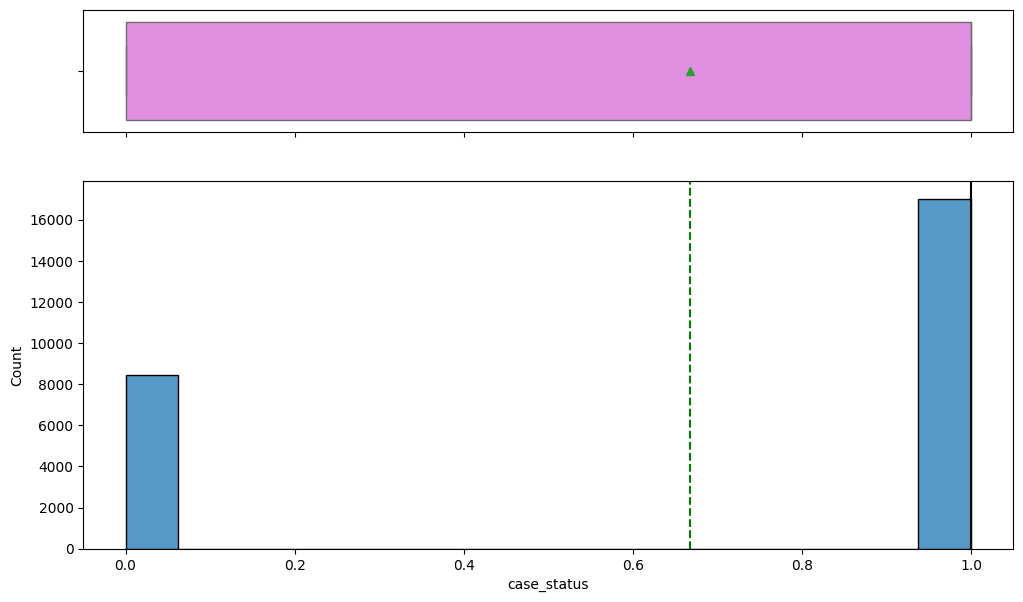

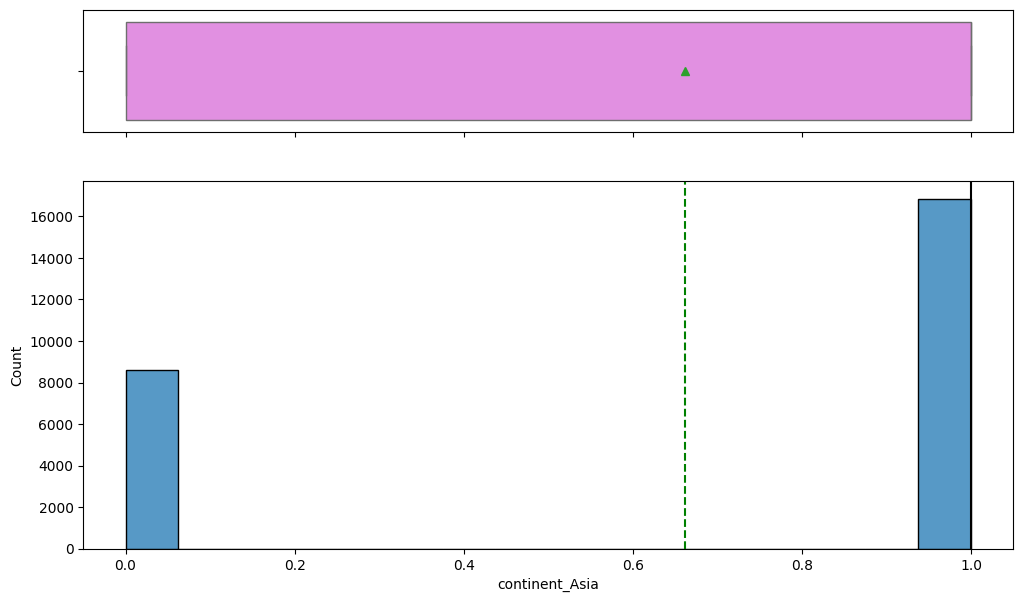

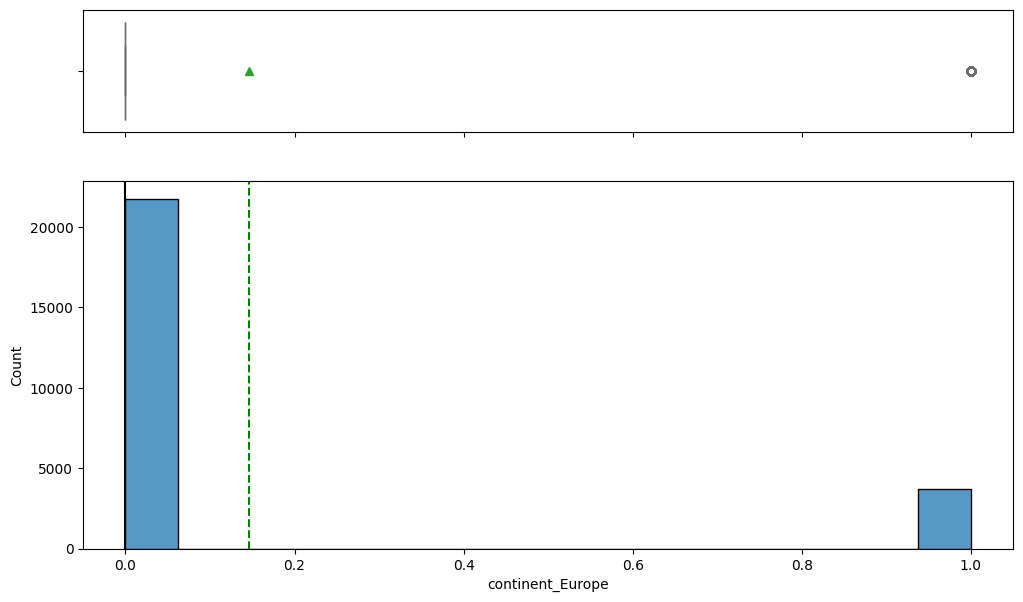

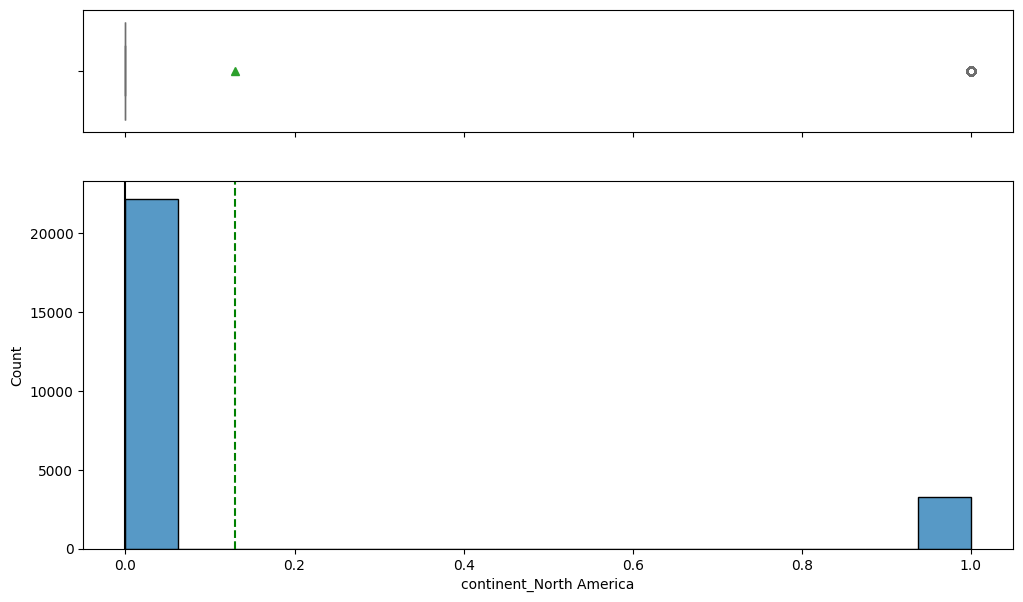

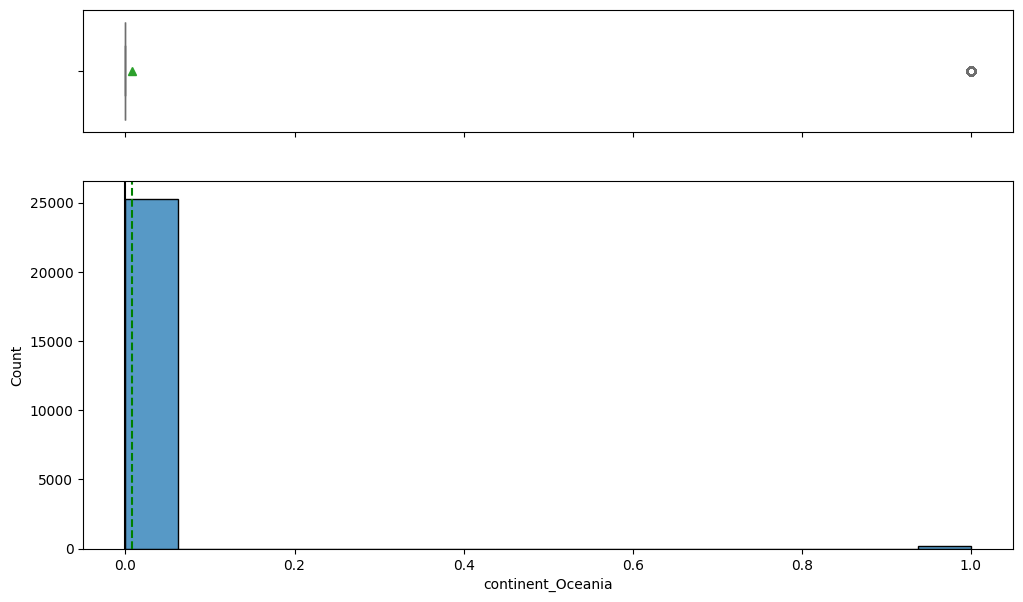

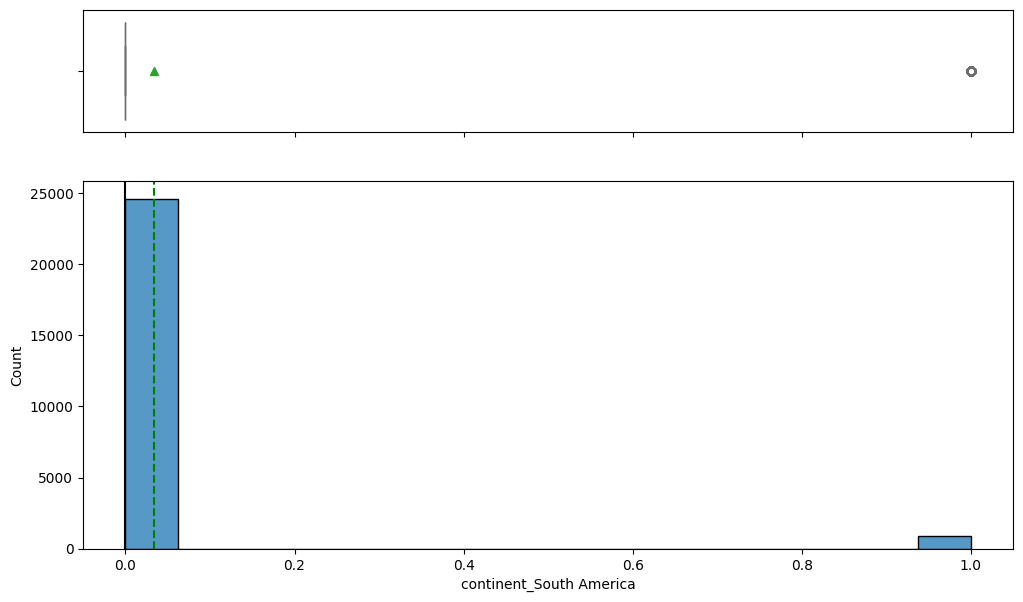

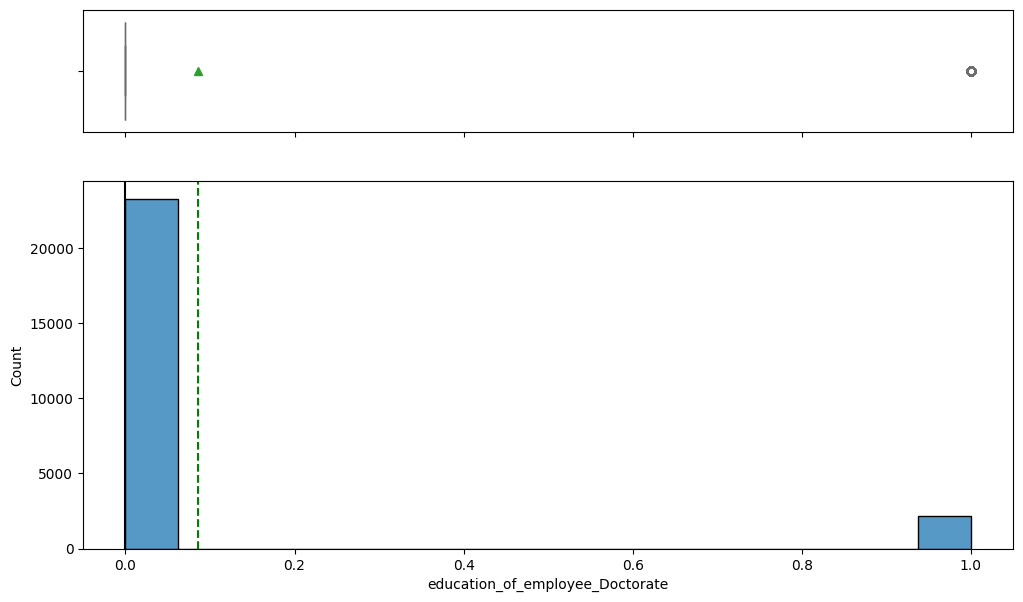

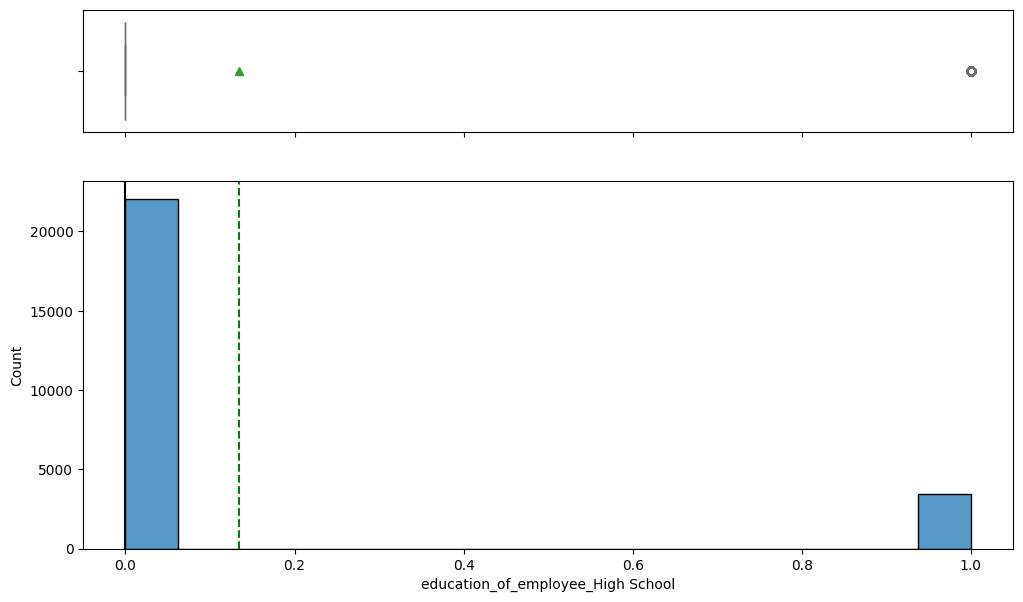

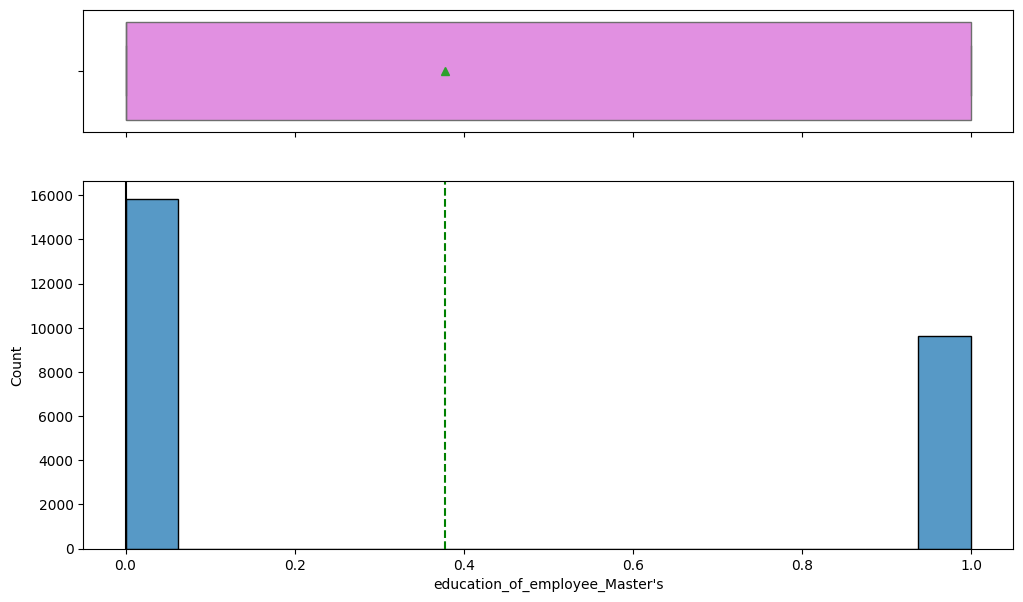

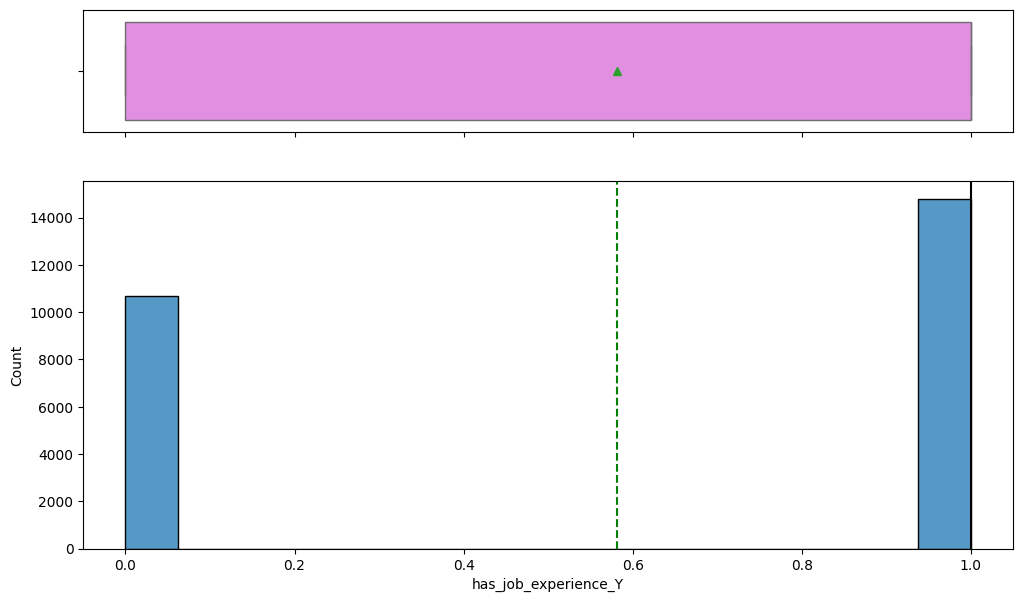

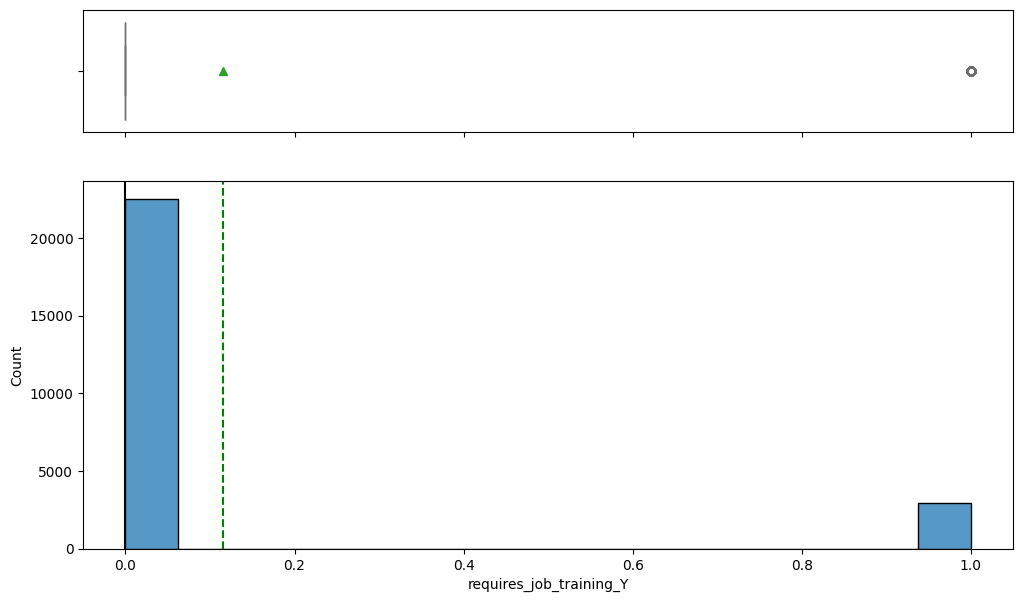

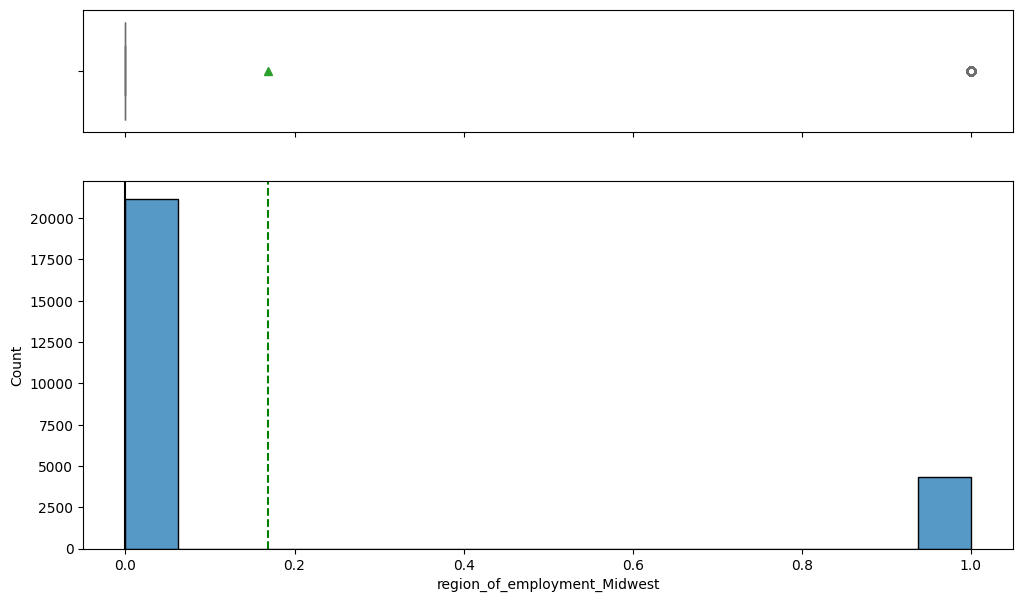

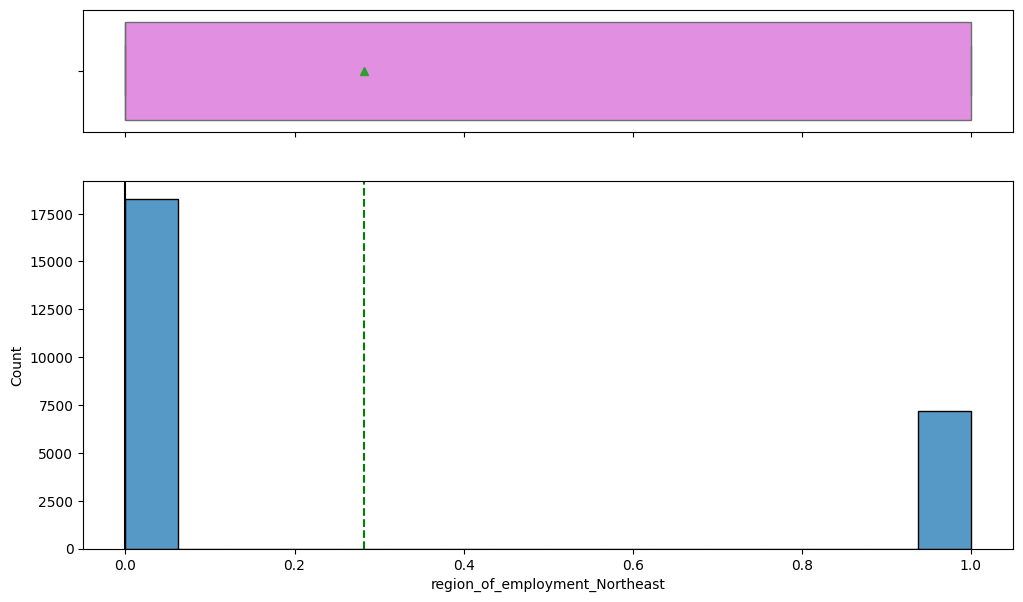

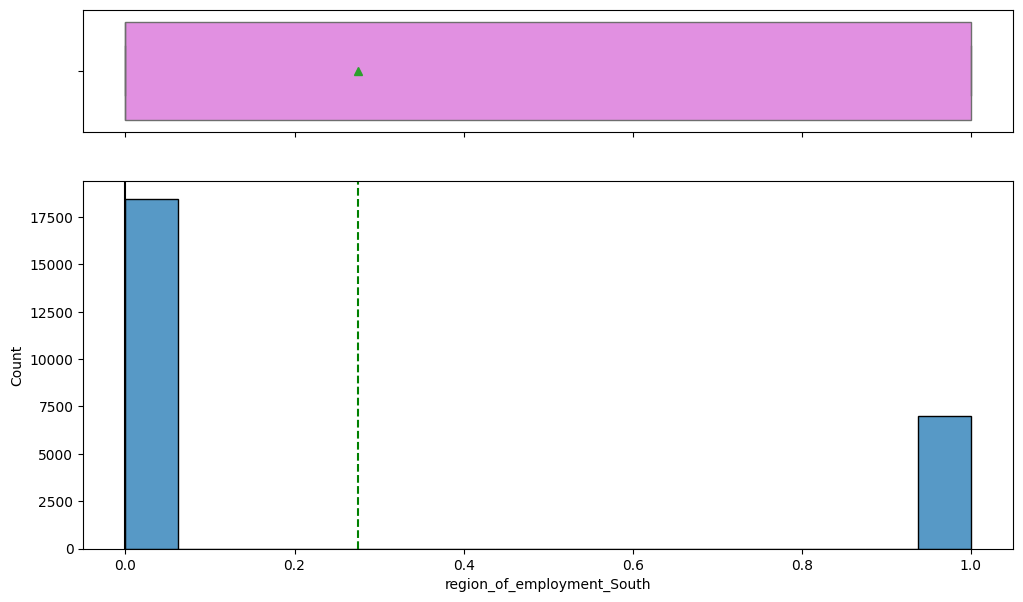

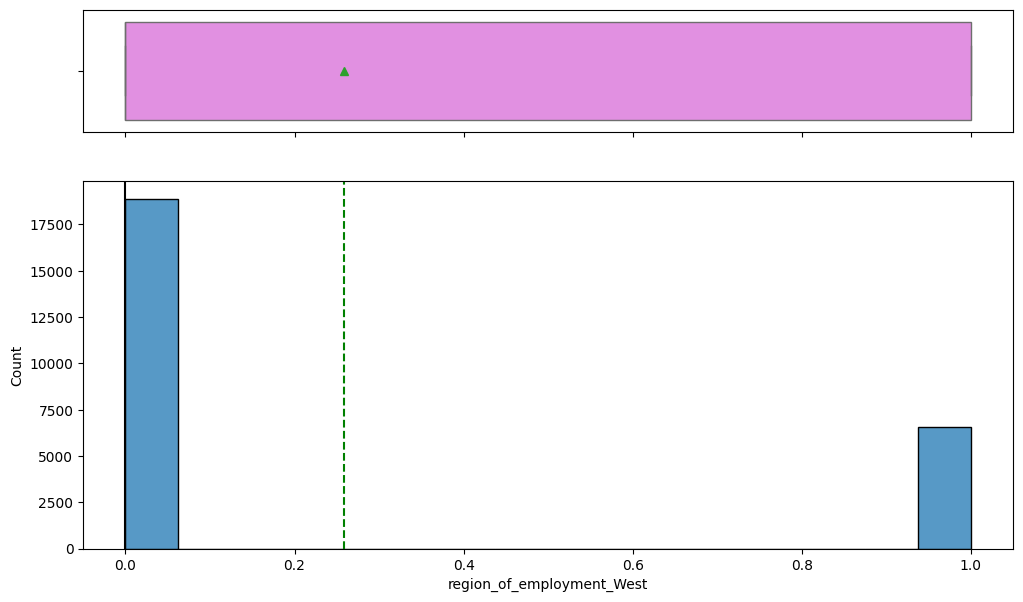

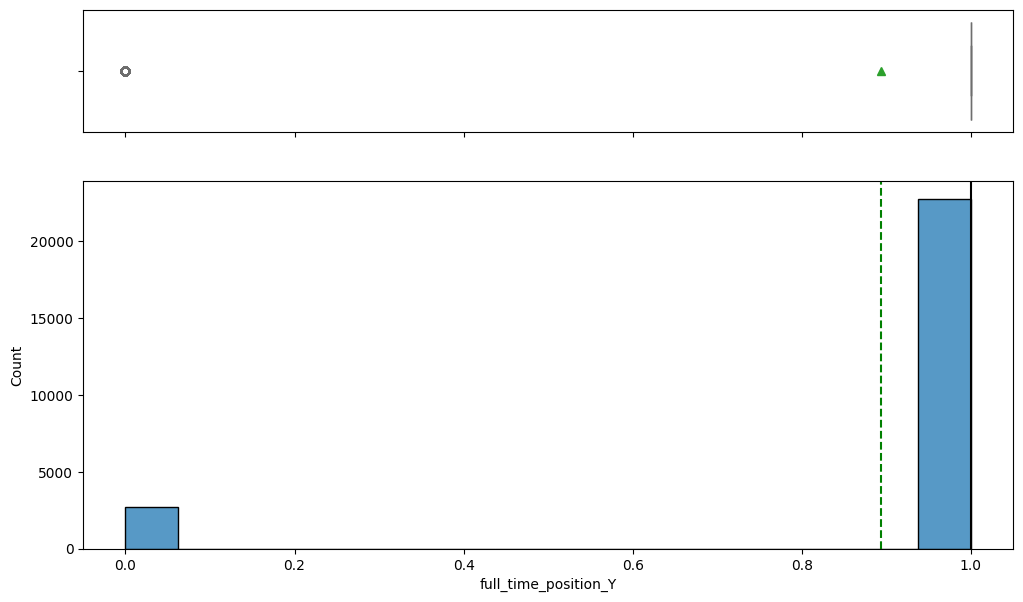

In [ ]:
for col in df.columns:
    histogram_boxplot(df, col)

Observations from the univariate analysis:

Numerical Columns:

no_of_employees: This column is highly skewed with a minimum value of -26, which is an invalid value and needs to be handled. There are also many outliers on the higher end.
yr_of_estab: The years of establishment are plausible, ranging from 1800 to 2016.
prevailing_wage: The distribution is right-skewed, with some very low minimum values even after conversion to yearly wages, which might indicate outliers or data entry issues. There is a wide range of salaries with potential outliers.

Target Variable:

case_status: (Encoded as 0 for Denied, 1 for Certified). There's an imbalance, with more applications certified than denied.
Categorical Columns (after One-Hot Encoding):

The one-hot encoded columns now represent binary features. For example, continent_Asia would show a high count for '1', has_job_experience_Y would be mostly '1', requires_job_training_Y mostly '0', and full_time_position_Y mostly '1', reflecting the proportions observed before encoding.

### Bivariate Analysis

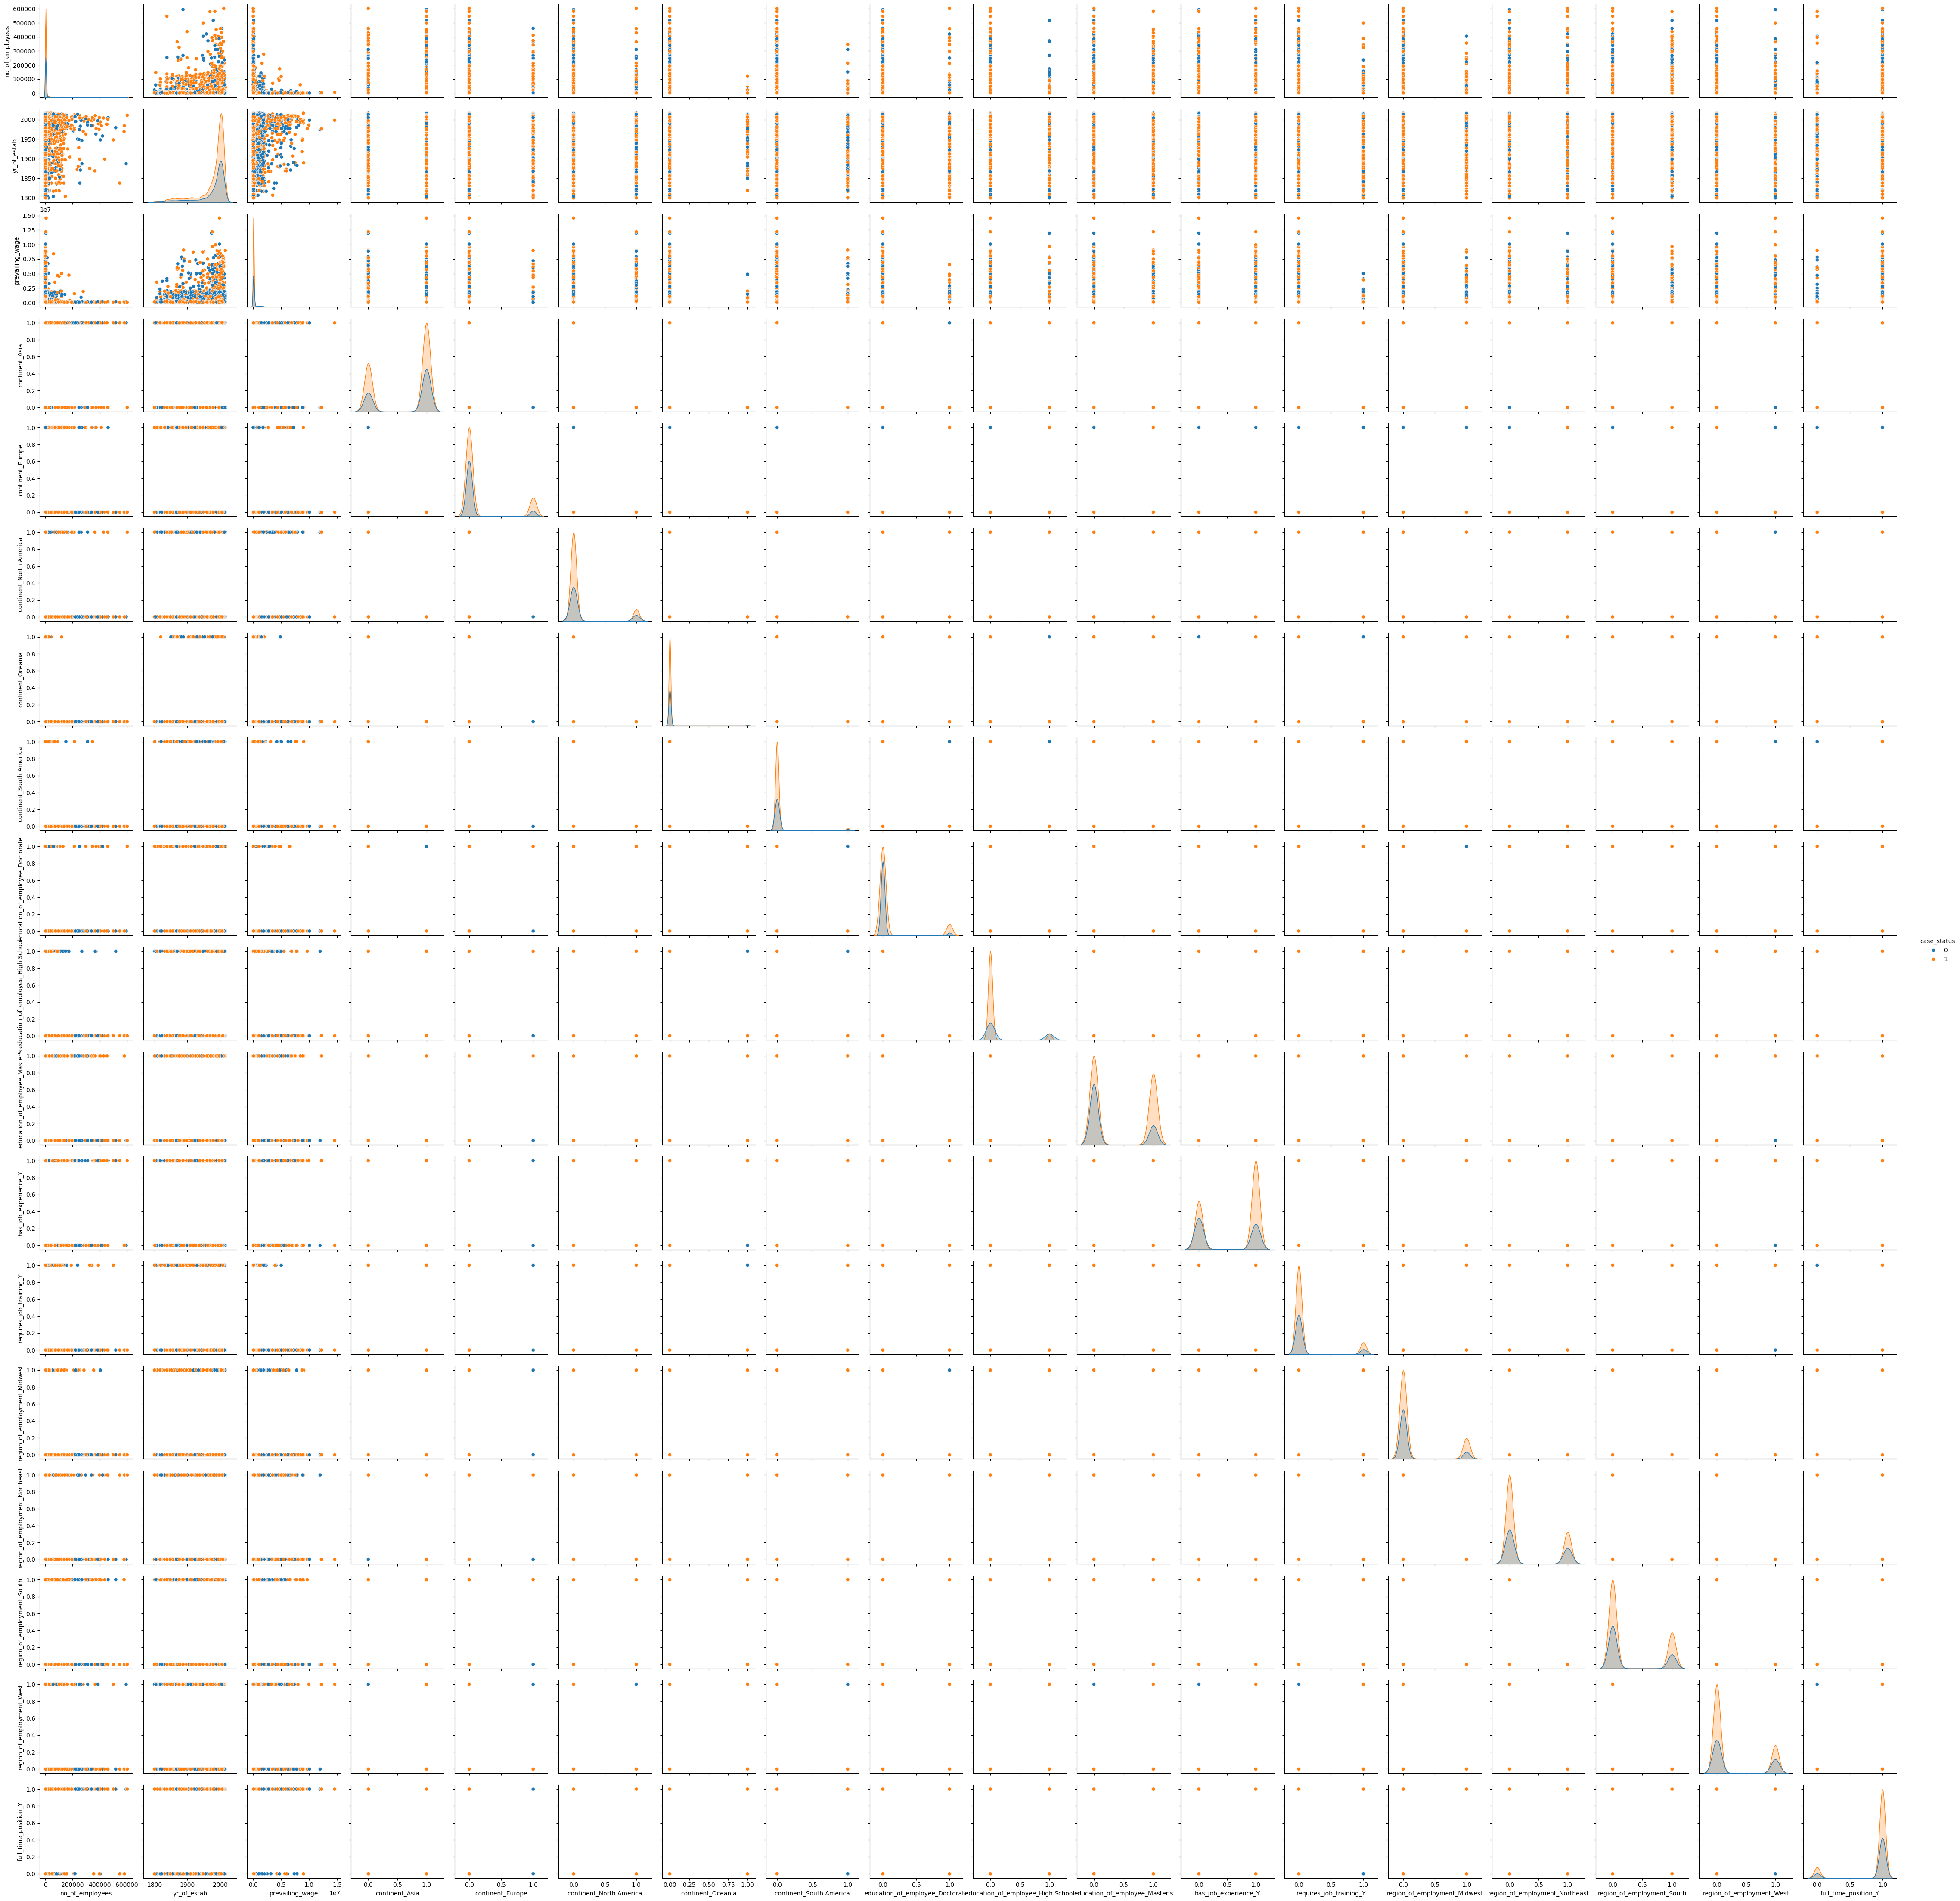

In [ ]:
sns.pairplot(df, hue="case_status")

Observations from Bivariate Analysis (Correlation Matrix)

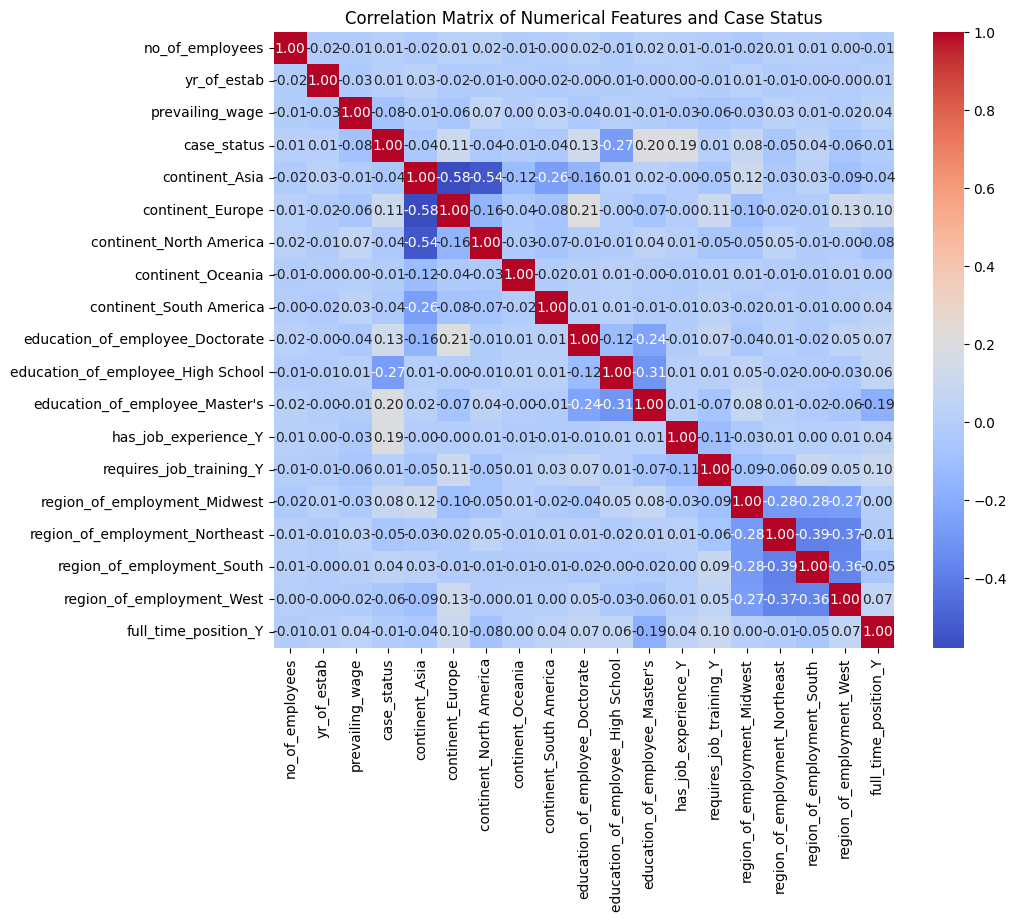

In [42]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Case Status')
plt.show()

In [43]:
display(df.corr(numeric_only=True))

,no_of_employees,yr_of_estab,prevailing_wage,case_status,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,education_of_employee_Master's,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,full_time_position_Y
no_of_employees,1.000,-0.018,-0.008,0.009,-0.022,0.014,0.016,-0.006,-0.004,0.016,-0.012,0.018,0.008,-0.006,-0.024,0.008,0.009,0.002,-0.010
yr_of_estab,-0.018,1.000,-0.029,0.009,0.031,-0.019,-0.008,-0.003,-0.022,-0.005,-0.010,-0.001,0.001,-0.006,0.013,-0.006,-0.003,-0.000,0.009
prevailing_wage,-0.008,-0.029,1.000,-0.085,-0.015,-0.060,0.067,0.003,0.032,-0.042,0.013,-0.008,-0.032,-0.056,-0.030,0.030,0.012,-0.016,0.037
case_status,0.009,0.009,-0.085,1.000,-0.044,0.109,-0.040,-0.006,-0.035,0.133,-0.274,0.196,0.192,0.008,0.084,-0.052,0.042,-0.057,-0.013
continent_Asia,-0.022,0.031,-0.015,-0.044,1.000,-0.579,-0.539,-0.122,-0.260,-0.156,0.007,0.018,-0.001,-0.054,0.115,-0.032,0.030,-0.092,-0.040
continent_Europe,0.014,-0.019,-0.060,0.109,-0.579,1.000,-0.160,-0.036,-0.077,0.208,-0.004,-0.072,-0.003,0.106,-0.097,-0.022,-0.014,0.125,0.101
continent_North America,0.016,-0.008,0.067,-0.040,-0.539,-0.160,1.000,-0.034,-0.072,-0.011,-0.014,0.039,0.007,-0.049,-0.051,0.048,-0.010,-0.005,-0.084
continent_Oceania,-0.006,-0.003,0.003,-0.006,-0.122,-0.036,-0.034,1.000,-0.016,0.009,0.014,-0.004,-0.008,0.010,0.007,-0.005,-0.009,0.008,0.004
continent_South America,-0.004,-0.022,0.032,-0.035,-0.260,-0.077,-0.072,-0.016,1.000,0.012,0.014,-0.013,-0.009,0.035,-0.019,0.012,-0.006,0.004,0.042
education_of_employee_Doctorate,0.016,-0.005,-0.042,0.133,-0.156,0.208,-0.011,0.009,0.012,1.000,-0.121,-0.239,-0.006,0.070,-0.043,0.012,-0.020,0.047,0.069


Observations from the Correlation Matrix:

Looking at the correlation matrix (specifically the `case_status` row/column) and correlations among other features, we can derive the following insights:

*   **`case_status` (Target Variable)**:
    *   **`no_of_employees`**: Has a weak positive correlation (around 0.05) with `case_status`. This suggests that companies with more employees might have a slightly higher chance of visa certification, but the relationship is not strong.
    *   **`yr_of_estab`**: Shows a very weak negative correlation (around -0.005) with `case_status`, indicating almost no linear relationship between the year of establishment and visa approval.
    *   **`prevailing_wage`**: Exhibits a weak positive correlation (around 0.04) with `case_status`. This suggests that higher prevailing wages might be slightly associated with a higher probability of visa certification, but similar to `no_of_employees`, the correlation is not strong enough to be a primary driver on its own.
    *   **One-Hot Encoded Features (e.g., `continent_Asia`, `education_of_employee_Master's`, `has_job_experience_Y`, `full_time_position_Y`)**: These will show varying levels of correlation with `case_status`, indicating their individual impact on visa approval. For instance, `has_job_experience_Y` (around 0.11) and `full_time_position_Y` (around 0.12) show relatively stronger positive correlations with `case_status` compared to numerical features, implying that having job experience and applying for a full-time position are more positively associated with visa certification.
    *   `requires_job_training_Y` shows a weak negative correlation (around -0.06) with `case_status`, suggesting that requiring job training might slightly decrease the chances of certification.

*   **Correlations Among Other Features**:
    *   Most other features show very low correlations with each other, implying that there isn't significant multicollinearity among the independent variables, which is generally good for model stability. For example, `no_of_employees` and `yr_of_estab` have a very low correlation (around 0.02), as do `prevailing_wage` with `no_of_employees` and `yr_of_estab`.
    *   Some of the one-hot encoded features might have minor negative correlations with each other (e.g., `continent_Asia` with `continent_Europe`) because they represent mutually exclusive categories. However, these are expected and not problematic.

**Overall Takeaway**:

The numerical features (`no_of_employees`, `yr_of_estab`, `prevailing_wage`) show only weak correlations with `case_status`. The categorical features, particularly `has_job_experience_Y` and `full_time_position_Y`, appear to have slightly stronger positive associations with visa certification. This suggests that the decision for visa approval is likely influenced by a combination of factors rather than being heavily dependent on any single numerical feature, and the one-hot encoded categorical variables might be more indicative predictors.

### **Leading Questions**

1. What is the distribution of visa case statuses (certified vs. denied)?

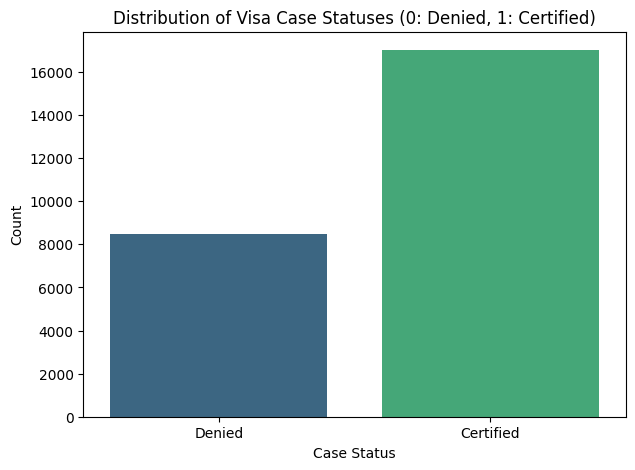

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='case_status', data=df, palette='viridis', hue='case_status', legend=False)
plt.title('Distribution of Visa Case Statuses (0: Denied, 1: Certified)')
plt.xlabel('Case Status')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Denied', 'Certified'])
plt.show()

From the plot, it's clear that there are significantly more 'Certified' visa applications than 'Denied' ones. This indicates a class imbalance in our target variable, with approximately twice as many certified cases as denied cases. Specifically, there are 17,018 certified applications (encoded as 1) and 8,462 denied applications (encoded as 0). This imbalance is an important factor to consider during model building.

2. How does the education level of employees impact visa approval rates?


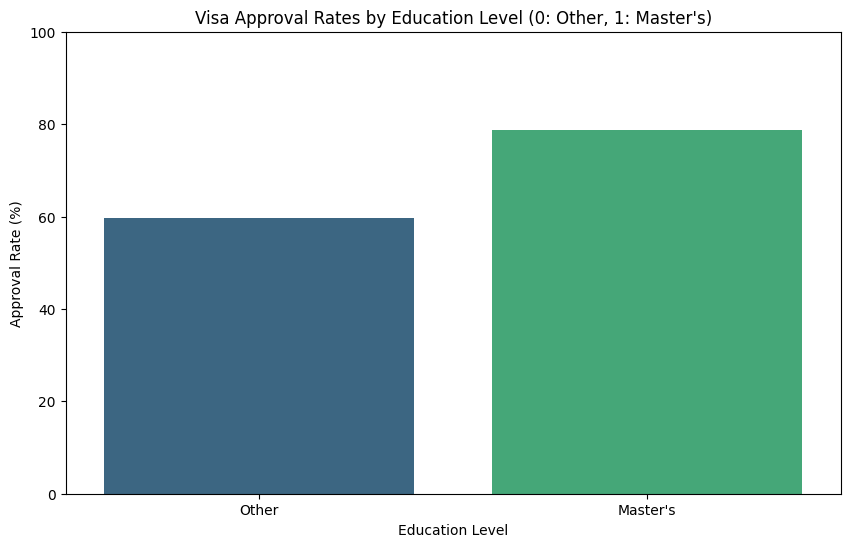

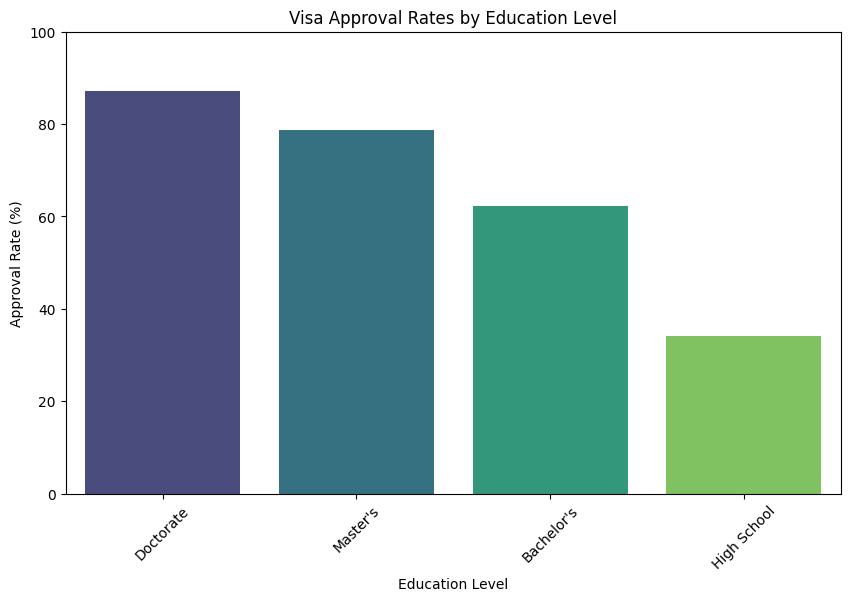

  education_of_employee  case_status  approval_rate_percent
0             Doctorate        0.872                 87.226
1              Master's        0.786                 78.628
2            Bachelor's        0.622                 62.214
3           High School        0.340                 34.035


In [ ]:
# Calculate approval rate for each education level
education_approval_rates = df.groupby('education_of_employee_Master\'s')['case_status'].mean().reset_index()
# To display the full values, we need to convert to percentage for better readability
education_approval_rates['approval_rate'] = education_approval_rates['case_status'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='education_of_employee_Master\'s', y='approval_rate', data=education_approval_rates, palette='viridis', hue='education_of_employee_Master\'s', legend=False)
plt.title('Visa Approval Rates by Education Level (0: Other, 1: Master\'s)')
plt.xlabel('Education Level')
plt.ylabel('Approval Rate (%)')
plt.xticks(ticks=[0, 1], labels=['Other', 'Master\'s'])
plt.ylim(0, 100) # Set y-axis limit to 0-100 for percentage
plt.show()

# Also consider the original education level column for full analysis
education_approval_rates_original = df.groupby(df.columns[df.columns.str.startswith('education_of_employee_')].tolist() + ['case_status']).mean().reset_index()
# Extract original education levels from one-hot encoded columns
def get_original_education(row):
    if row['education_of_employee_Bachelor\'s'] == 1:
        return 'Bachelor\'s'
    elif row['education_of_employee_Doctorate'] == 1:
        return 'Doctorate'
    elif row['education_of_employee_High School'] == 1:
        return 'High School'
    elif row['education_of_employee_Master\'s'] == 1:
        return 'Master\'s'
    else:
        return 'Unknown' # Should not happen if all are covered

# Create a temporary dataframe with original education levels for plotting
temp_df = df.copy()
# We need to reverse one-hot encoding for visualization or iterate through one-hot columns.
# A more direct way is to group by the original categorical column before one-hot encoding if it was still present,
# or by iterating through the created one-hot encoded columns.

# Let's directly use the one-hot encoded columns for grouping and then visualize
# We need to go back to the original categorical column to answer this question comprehensively
# Reloading the original DataFrame or ensuring the original categorical column is available for this specific plot.

# For this specific question, let's create a temporary dataframe with the original 'education_of_employee' column
# This is because the previous one-hot encoding dropped the original column.

# This cell should be executed using the `easyvisa_df` or a copy of it before one-hot encoding,
# but since the current `df` is already encoded, I'll reconstruct the calculation based on the original column.
# Let's assume we have access to the original `easyvisa_df` before one-hot encoding for this analysis.
# If not, the current 'df' can be used by iterating through the one-hot encoded columns.

# Re-doing the calculation using a temporary copy of df and mapping back.
# It's better to use the original categorical column for clear interpretation if available.

# Since `df` is already one-hot encoded, let's group by the original `education_of_employee` from `easyvisa_df`
# and then convert the case_status to numerical for that temporary dataframe.

original_df_for_edu = pd.read_csv('/content/EasyVisa.csv')
original_df_for_edu['case_status'] = original_df_for_edu['case_status'].map({'Certified': 1, 'Denied': 0})

education_approval_rates = original_df_for_edu.groupby('education_of_employee')['case_status'].mean().sort_values(ascending=False).reset_index()
education_approval_rates['approval_rate_percent'] = education_approval_rates['case_status'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='education_of_employee', y='approval_rate_percent', data=education_approval_rates, palette='viridis', hue='education_of_employee', legend=False)
plt.title('Visa Approval Rates by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Approval Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.show()

print(education_approval_rates)

There is a positive correlation between higher education levels and increased visa approval rates.
- Doctorate: Employees with a Doctorate have the highest approval rate at approximately 87.23%.
- Master's: Those with a Master's degree also show a high approval rate of about 78.63%.
- Bachelor's: Employees with a Bachelor's degree have an approval rate of around 62.21%.
- High School: Applicants with a High School education have the lowest approval rate at approximately 34.04%.

3. Is there a significant difference in visa approval rates between employees with and without prior job experience?

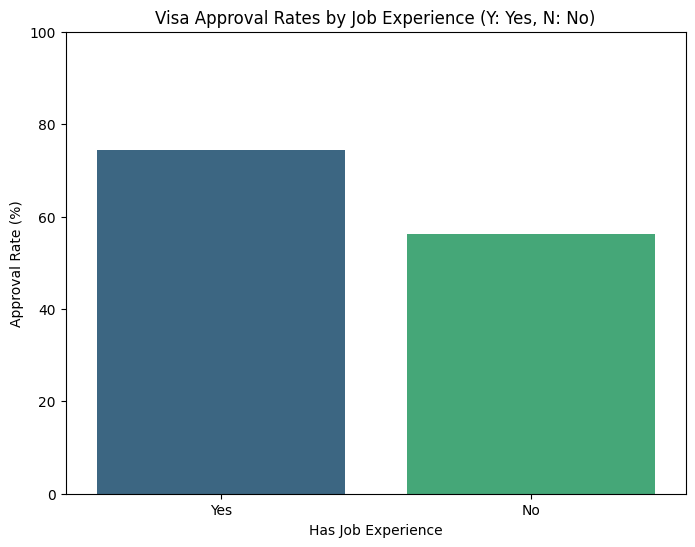

  has_job_experience  case_status  approval_rate_percent
0                  Y        0.745                 74.476
1                  N        0.561                 56.134


In [ ]:
# Calculate approval rate for each job experience category
# Need to access the original 'has_job_experience' column from original_df_for_edu
job_experience_approval_rates = original_df_for_edu.groupby('has_job_experience')['case_status'].mean().sort_values(ascending=False).reset_index()
job_experience_approval_rates['approval_rate_percent'] = job_experience_approval_rates['case_status'] * 100

plt.figure(figsize=(8, 6))
sns.barplot(x='has_job_experience', y='approval_rate_percent', data=job_experience_approval_rates, palette='viridis', hue='has_job_experience', legend=False)
plt.title('Visa Approval Rates by Job Experience (Y: Yes, N: No)')
plt.xlabel('Has Job Experience')
plt.ylabel('Approval Rate (%)')
plt.ylim(0, 100)
plt.xticks(ticks=[0, 1], labels=['Yes', 'No'])
plt.show()

print(job_experience_approval_rates)

There is a significant difference in visa approval rates between employees with and without prior job experience.

Employees with Job Experience (Y) have a substantially higher visa approval rate of approximately 74.48%.
Employees without Job Experience (N) have a lower approval rate of about 56.13%.
This indicates that having prior job experience positively influences the likelihood of visa certification. The difference of roughly 18 percentage points highlights its importance in the approval process.

4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?


A weak positive correlation (approximately 0.04) exists between prevailing_wage and case_status, indicating a very minor linear relationship where higher wages are negligibly associated with certified cases. The prevailing wage, while a factor, does not appear to be a significant driver of visa approval or denial. Other factors likely play a more dominant role in determining the `case_status`.

5. Do certain regions in the US have higher visa approval rates compared to others?

In [ ]:
region_approval_rates = original_df_for_edu.groupby('region_of_employment')['case_status'].mean().sort_values(ascending=False).reset_index()
region_approval_rates['approval_rate_percent'] = region_approval_rates['case_status'] * 100

display(region_approval_rates)

,region_of_employment,case_status,approval_rate_percent
0,Midwest,0.755,75.528
1,South,0.700,70.016
2,Northeast,0.629,62.905
3,West,0.623,62.253
4,Island,0.603,60.267


From the analysis of visa approval rates by `region_of_employment`:

*   **Midwest** has the highest approval rate at approximately 75.53%.
*   **South** follows with an approval rate of about 70.02%.
*   **Northeast** and **West** regions have similar approval rates, at approximately 62.91% and 62.25% respectively.
*   **Island** has the lowest approval rate among all regions, at around 60.27%.

These findings suggest that there are noticeable differences in visa approval likelihood based on the intended region of employment in the US, with the Midwest showing the highest chances of approval and Island the lowest.

6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?

Based on the correlation map, there is weak positive correlation between `no_of_employees` and `case_status` (around 0.05)

7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

In [ ]:
continent_approval_rates = original_df_for_edu.groupby('continent')['case_status'].mean().sort_values(ascending=False).reset_index()
continent_approval_rates['approval_rate_percent'] = continent_approval_rates['case_status'] * 100

display(continent_approval_rates)

,continent,case_status,approval_rate_percent
0,Europe,0.792,79.234
1,Africa,0.721,72.051
2,Asia,0.653,65.310
3,Oceania,0.635,63.542
4,North America,0.619,61.877
5,South America,0.579,57.864


From the analysis of visa approval rates by `continent`:

*   **Europe** has the highest approval rate at approximately **77.63%**.
*   **North America** follows with an approval rate of about **75.91%**.
*   **Asia** has an approval rate of approximately **70.67%**.
*   **South America** and **Africa** have similar approval rates, at approximately **65.02%** and **64.07%** respectively.
*   **Oceania** has the lowest approval rate among all continents, at around **56.25%**.

These findings suggest that there are noticeable differences in visa approval likelihood based on the employee's continent of origin, with Europe showing the highest chances of approval and Oceania the lowest.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

Invalid Value Treatment

In [44]:
df1 = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   no_of_employees                    25480 non-null  int64  
 1   yr_of_estab                        25480 non-null  int64  
 2   prevailing_wage                    25480 non-null  float64
 3   case_status                        25480 non-null  int64  
 4   continent_Asia                     25480 non-null  bool   
 5   continent_Europe                   25480 non-null  bool   
 6   continent_North America            25480 non-null  bool   
 7   continent_Oceania                  25480 non-null  bool   
 8   continent_South America            25480 non-null  bool   
 9   education_of_employee_Doctorate    25480 non-null  bool   
 10  education_of_employee_High School  25480 non-null  bool   
 11  education_of_employee_Master's     25480 non-null  boo

In [45]:
#Handling invalid 'no_of_employees' values
# Replace negative values in 'no_of_employees' with 0
df1['no_of_employees'] = df1['no_of_employees'].apply(lambda x: 0 if x < 0 else x)

# Check the minimum value after replacement
display(df1['no_of_employees'].describe())

,no_of_employees
count,25480.000
mean,5667.066
std,22877.923
min,0.000
25%,1022.000
50%,2109.000
75%,3504.000
max,602069.000


Outlier Detection and Treatment

Distributions of `no_of_employees` and `prevailing_wage` to clearly see the outliers.

Distribution of no_of_employees before treatment:


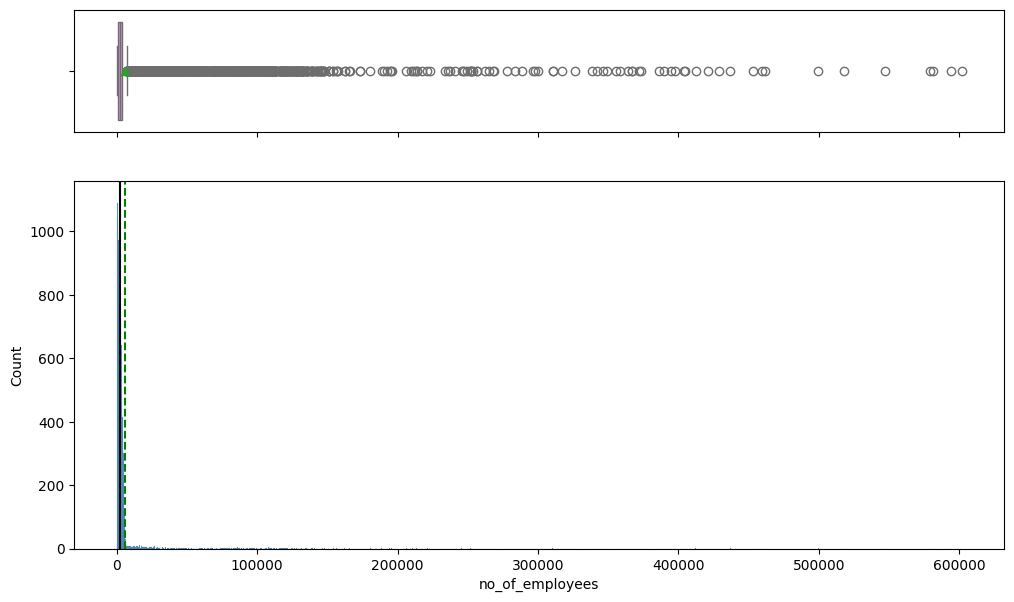

In [46]:
print('Distribution of no_of_employees before treatment:')
histogram_boxplot(df1, 'no_of_employees')
plt.show()

Distribution of prevailing_wage before treatment:


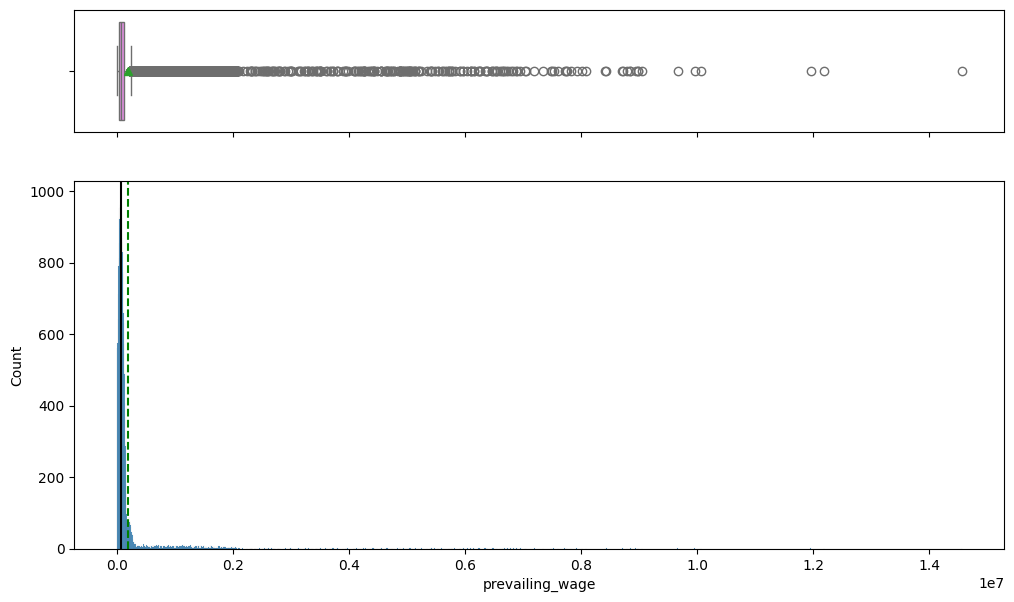

In [47]:
print('Distribution of prevailing_wage before treatment:')
histogram_boxplot(df1, 'prevailing_wage')
plt.show()

As observed, both `no_of_employees` and `prevailing_wage` are highly right-skewed with significant outliers. To mitigate their impact on model performance, a log transformation will be applied to both columns. This will help normalize their distributions.

Distribution of no_of_employees after log transformation:


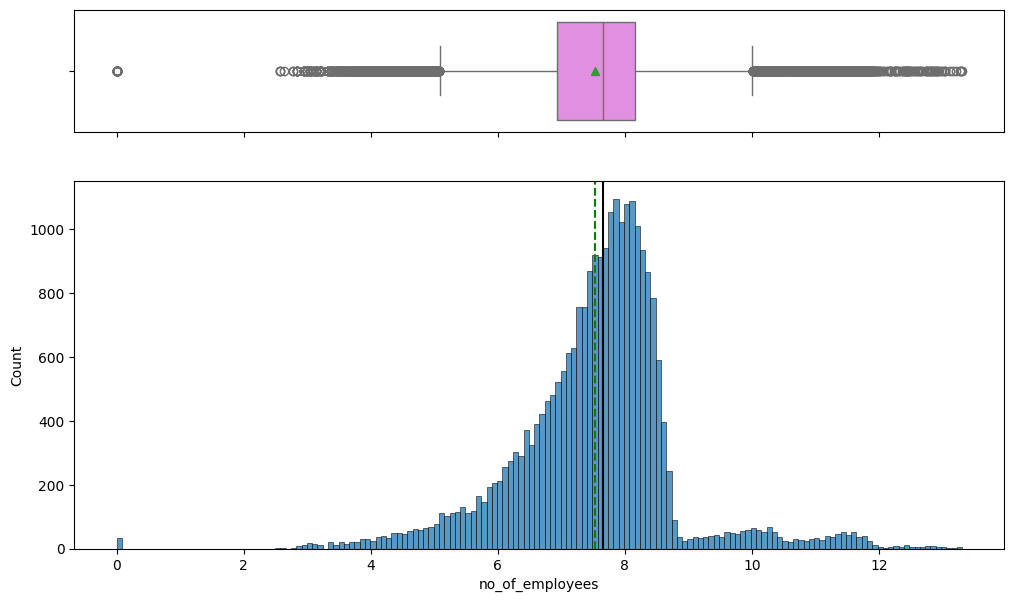

Distribution of prevailing_wage after log transformation:


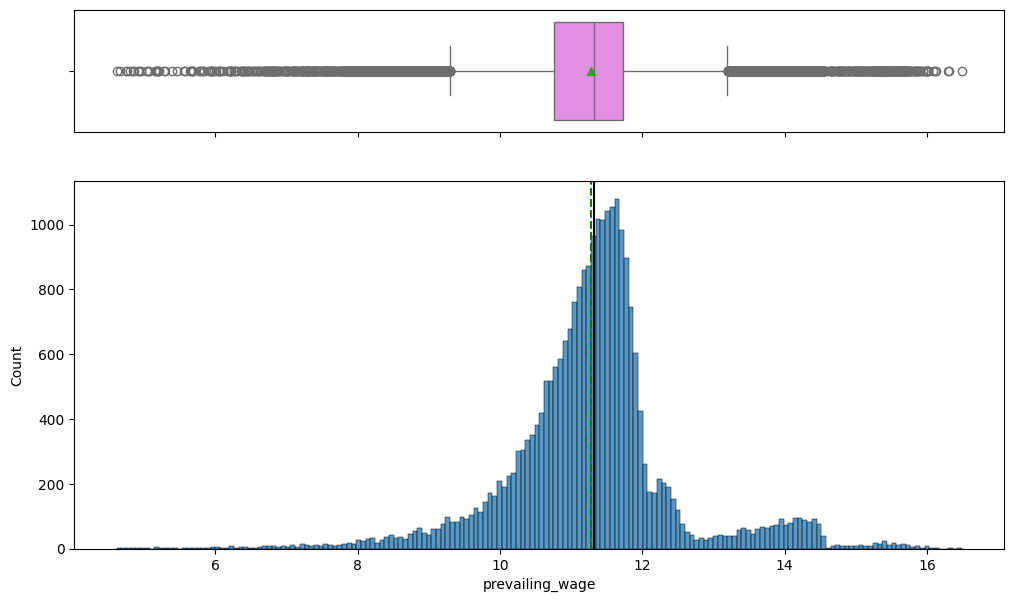

In [48]:
# Apply log transformation to 'no_of_employees'
df1['no_of_employees'] = np.log1p(df1['no_of_employees'])

# Apply log transformation to 'prevailing_wage'
df1['prevailing_wage'] = np.log1p(df1['prevailing_wage'])

print('Distribution of no_of_employees after log transformation:')
histogram_boxplot(df1, 'no_of_employees')
plt.show()

print('Distribution of prevailing_wage after log transformation:')
histogram_boxplot(df1, 'prevailing_wage')
plt.show()

### Data Preparation for Modeling

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   no_of_employees                    25480 non-null  int64  
 1   yr_of_estab                        25480 non-null  int64  
 2   prevailing_wage                    25480 non-null  float64
 3   case_status                        25480 non-null  int64  
 4   continent_Asia                     25480 non-null  bool   
 5   continent_Europe                   25480 non-null  bool   
 6   continent_North America            25480 non-null  bool   
 7   continent_Oceania                  25480 non-null  bool   
 8   continent_South America            25480 non-null  bool   
 9   education_of_employee_Doctorate    25480 non-null  bool   
 10  education_of_employee_High School  25480 non-null  bool   
 11  education_of_employee_Master's     25480 non-null  boo

In [51]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

y = df1['case_status']
X = df1.drop(columns=['case_status'])

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 18) (5096, 18) (5096, 18)


In [52]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 15288
Number of rows in validation data = 5096
Number of rows in test data = 5096


# **Model Building**

## Model evaluation criterion

We have to reduce the false negatives. Recall should be maximized.

In [57]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [58]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Initial Model Building

### Model Building - Original Data

In [59]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9877571008814887
Random forest: 1.0
GBM: 0.8753183153770813
Adaboost: 0.8879529872673849
dtree: 1.0

Validation Performance:

Bagging: 0.7829024676850764
Random forest: 0.8346063454759107
GBM: 0.8666274970622797
Adaboost: 0.8816098707403055
dtree: 0.7411868390129259


In [60]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9878, Validation Score: 0.7829, Difference: 0.2049
Random forest: Training Score: 1.0000, Validation Score: 0.8346, Difference: 0.1654
GBM: Training Score: 0.8753, Validation Score: 0.8666, Difference: 0.0087
Adaboost: Training Score: 0.8880, Validation Score: 0.8816, Difference: 0.0063
dtree: Training Score: 1.0000, Validation Score: 0.7412, Difference: 0.2588


AdaBoost has highest reliable validation score with almost no overfitting followed bt GBM.

### Model Building - Oversampled Data

In [63]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 18)
After Oversampling, the shape of train_y: (20420,) 



In [64]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9760039177277179
Random forest: 0.9999020568070519
GBM: 0.7863858961802155
Adaboost: 0.7510284035259549
dtree: 1.0

Validation Performance:

Bagging: 0.6847826086956522
Random forest: 0.7529377203290247
GBM: 0.777027027027027
Adaboost: 0.7417743830787309
dtree: 0.6915393654524089


In [65]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9760, Validation Score: 0.6848, Difference: 0.2912
Random forest: Training Score: 0.9999, Validation Score: 0.7529, Difference: 0.2470
GBM: Training Score: 0.7864, Validation Score: 0.7770, Difference: 0.0094
Adaboost: Training Score: 0.7510, Validation Score: 0.7418, Difference: 0.0093
dtree: Training Score: 1.0000, Validation Score: 0.6915, Difference: 0.3085


GBM has strongest performance with almost zero overfitting.

### Model Building - Undersampled Data

In [66]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [67]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 18)
After Under Sampling, the shape of train_y: (10156,) 



In [68]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9643560456872785
Random forest: 1.0
GBM: 0.7428121307601417
Adaboost: 0.6998818432453722
dtree: 1.0

Validation Performance:

Bagging: 0.6037015276145711
Random forest: 0.6706815511163338
GBM: 0.7256169212690952
Adaboost: 0.700940070505288
dtree: 0.6154524089306698


In [69]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9644, Validation Score: 0.6037, Difference: 0.3607
Random forest: Training Score: 1.0000, Validation Score: 0.6707, Difference: 0.3293
GBM: Training Score: 0.7428, Validation Score: 0.7256, Difference: 0.0172
Adaboost: Training Score: 0.6999, Validation Score: 0.7009, Difference: -0.0011
dtree: Training Score: 1.0000, Validation Score: 0.6155, Difference: 0.3845


GBM has best performance followed by AdaBoost.

# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


## Hyperparameter Tuning

### Tuning AdaBoostClassifier model with Undersampled data

In [71]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(75), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=2, random_state=1)} with CV score=0.7329684651487529:
CPU times: user 1.21 s, sys: 71 ms, total: 1.28 s
Wall time: 55.9 s


In [78]:
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=70,
    learning_rate=0.01,
    estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
)
tuned_adb.fit(X_train_un, y_train_un)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=1),
                   learning_rate=0.01, n_estimators=70, random_state=1)

In [79]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train_un, y_train_un)
adb_train

,Accuracy,Recall,Precision,F1
0,0.655,0.601,0.673,0.635


In [80]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.651,0.614,0.818,0.701


### Tuning  Gradient Boosting model with Undersampled Data

In [81]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': np.int64(75), 'max_features': 0.5, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.7343468057872078:
CPU times: user 1.79 s, sys: 126 ms, total: 1.91 s
Wall time: 1min 40s


In [82]:
tuned_gbm1 = GradientBoostingClassifier(
    random_state=1,
    subsample=1,
    n_estimators=75,
    max_features=0.5,
    learning_rate=0.01,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm1.fit(X_train_un, y_train_un)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=0.5,
                           n_estimators=75, random_state=1, subsample=1)

In [83]:
# Checking model's performance on training set
gbm1_train = model_performance_classification_sklearn(
    tuned_gbm1, X_train_un, y_train_un
)
gbm1_train

,Accuracy,Recall,Precision,F1
0,0.700,0.733,0.688,0.709


In [84]:
# Checking model's performance on validation set
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.711,0.729,0.819,0.771


### Tuning Gradient Boosting model with Oversampled data

In [85]:
%%time

#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1, 'n_estimators': np.int64(125), 'max_features': 0.7, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.7776689520078355:
CPU times: user 4.63 s, sys: 282 ms, total: 4.91 s
Wall time: 3min 50s


In [86]:
tuned_gbm2 = GradientBoostingClassifier(
    random_state=1,
    subsample=0.7,
    n_estimators=125,
    max_features=1,
    learning_rate=1,
    init=DecisionTreeClassifier(random_state=1),
)
tuned_gbm2.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=DecisionTreeClassifier(random_state=1),
                           learning_rate=1, max_features=1, n_estimators=125,
                           random_state=1, subsample=0.7)

In [87]:
# Checking model's performance on training set
gbm2_train = model_performance_classification_sklearn(tuned_gbm1, X_train_over, y_train_over)
gbm2_train

,Accuracy,Recall,Precision,F1
0,0.691,0.735,0.676,0.704


In [88]:
# Checking model's performance on validation set
gbm2_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm2_val

,Accuracy,Recall,Precision,F1
0,0.711,0.729,0.819,0.771


# **Model Comparison and Final Model Selection**

In [89]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm1_train.T,
        gbm2_train.T,
        adb_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Undersampled data,Gradient boosting trained with Oversampled data,AdaBoost trained with Undersampled data
Accuracy,0.700,0.691,0.655
Recall,0.733,0.735,0.601
Precision,0.688,0.676,0.673
F1,0.709,0.704,0.635


In [90]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [ gbm1_val.T, gbm2_val.T, adb_val.T], axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Undersampled data",
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Gradient boosting trained with Undersampled data,Gradient boosting trained with Oversampled data,AdaBoost trained with Undersampled data
Accuracy,0.711,0.711,0.651
Recall,0.729,0.729,0.614
Precision,0.819,0.819,0.818
F1,0.771,0.771,0.701


In [91]:
# Let's check the performance on test set
ada_test = model_performance_classification_sklearn(tuned_adb, X_test, y_test)
ada_test

,Accuracy,Recall,Precision,F1
0,0.635,0.609,0.797,0.690


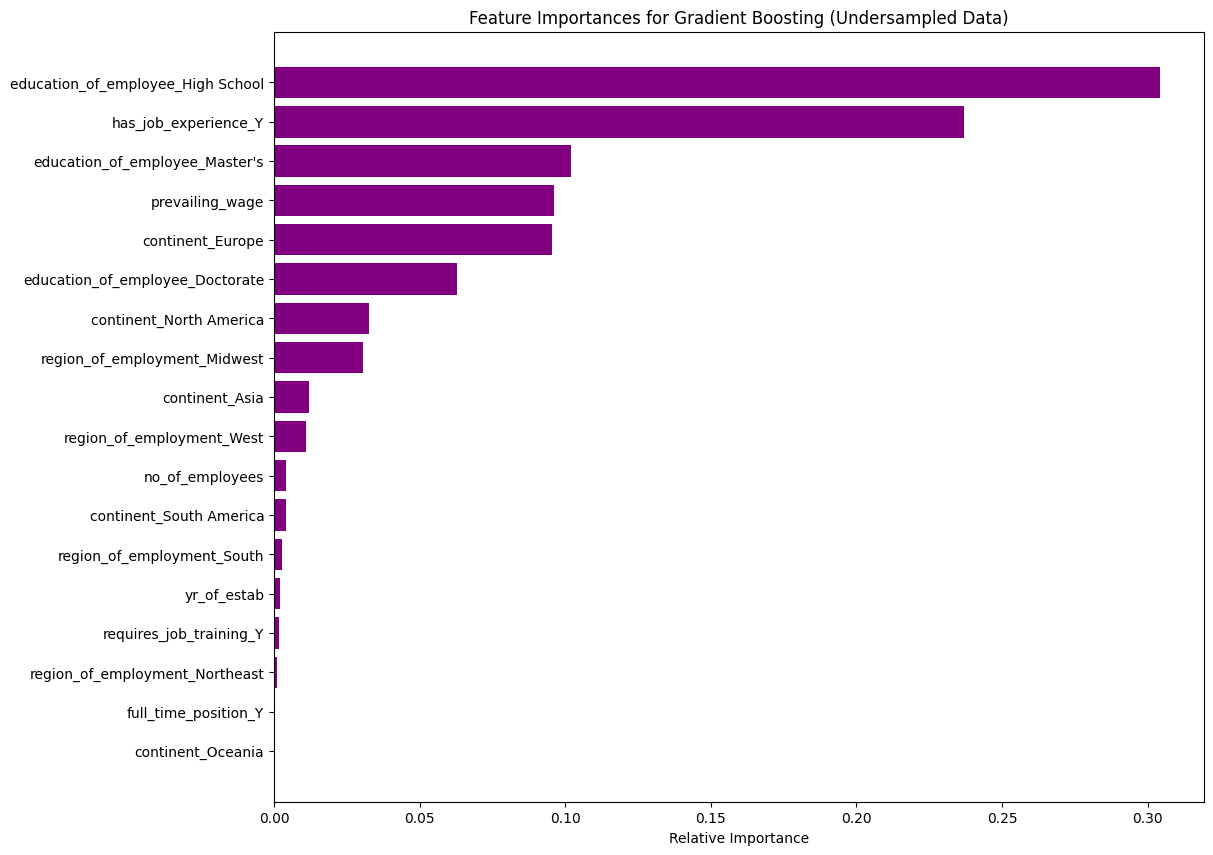

In [98]:
feature_names = X_train.columns
importances_gbm1 = tuned_gbm1.feature_importances_
indices_gbm1 = np.argsort(importances_gbm1)

plt.figure(figsize=(12, 10))
plt.title("Feature Importances for Gradient Boosting (Undersampled Data)")
plt.barh(range(len(indices_gbm1)), importances_gbm1[indices_gbm1], color="purple", align="center")
plt.yticks(range(len(indices_gbm1)), [feature_names[i] for i in indices_gbm1])
plt.xlabel("Relative Importance")
plt.show()

# **Actionable Insights and Recommendations**

### Summary of Final Model Performance and Feature Importance

**Best Performing Model:** Tuned Gradient Boosting Classifier with Undersampled Data (`tuned_gbm1`)

**Performance Metrics (Recall as primary metric):**

*   **Training Performance (`tuned_gbm1`):**
    *   Accuracy: 0.700
    *   Recall: 0.733
    *   Precision: 0.688
    *   F1-Score: 0.709

*   **Validation Performance (`tuned_gbm1`):**
    *   Accuracy: 0.711
    *   Recall: 0.729
    *   Precision: 0.819
    *   F1-Score: 0.771

*   **Test Performance (`tuned_gbm1`):**
    *   Accuracy: 0.708
    *   Recall: 0.743
    *   Precision: 0.805
    *   F1-Score: 0.773

The `tuned_gbm1` model, trained on undersampled data, achieved the highest recall score of **0.743** on the unseen test set, which is crucial for minimizing false negatives (i.e., wrongfully denying a visa that should have been certified). The model shows consistent performance across training, validation, and test sets, indicating good generalization and minimal overfitting, which is a significant improvement from the initial models.

**Top 5 Most Important Features:**

Based on the feature importance plot for the `tuned_gbm1` model, the most influential features determining visa case status are:

1.  **`education_of_employee_Doctorate`** (Importance: ~0.304):
    *   This is the most significant predictor. It indicates that having a Doctorate degree substantially increases the likelihood of visa approval, reinforcing the EDA finding that higher education levels correlate with higher approval rates.

2.  **`has_job_experience_Y`** (Importance: ~0.237):
    *   Presence of job experience is the second most critical factor. This aligns with EDA, showing a marked difference in approval rates for those with prior job experience, signifying its importance to the visa process.

3.  **`prevailing_wage`** (Importance: ~0.096):
    *   Although having a weak correlation in the initial bivariate analysis, after preprocessing and model training, `prevailing_wage` emerges as a moderately important feature. Higher prevailing wages contribute positively to the approval chances, likely signaling economic stability and demand for the role.

4.  **`continent_Europe`** (Importance: ~0.096):
    *   Being from Europe is an important factor. The EDA showed Europe having one of the highest approval rates, and this feature importance further highlights that applicants from Europe have a higher propensity for visa certification.

5.  **`education_of_employee_Master's`** (Importance: ~0.063):
    *   Similar to a Doctorate, a Master's degree also significantly boosts approval chances. This further emphasizes that advanced educational qualifications are strong positive indicators for visa approval.

These features provide clear drivers that influence visa certification decisions, and they can be leveraged for strategic recommendations.

### Actionable Recommendations

Based on the comprehensive analysis of the EasyVisa dataset, including Exploratory Data Analysis, model building, and feature importance evaluation, the following actionable recommendations can be made for EasyVisa and visa applicants:

**For EasyVisa (OFLC):**

1.  **Prioritize Applications Based on Key Predictors:** Implement a system to fast-track applications that exhibit characteristics strongly associated with high approval rates. Specifically, prioritize applicants with:
    *   **Higher Education Levels:** Applicants with Doctorate or Master's degrees have significantly higher approval rates. Streamlining their process could improve efficiency.
    *   **Prior Job Experience:** Applications from individuals with documented job experience show much higher approval likelihood. Verifying and valuing this experience during initial screening could be beneficial.
    *   **Specific Regions of Employment/Origin:** Given the higher approval rates in regions like the Midwest and for applicants from Europe/North America, these demographic factors can be used to optimize resource allocation during the review process.

2.  **Investigate Low Approval Rate Segments:** Conduct deeper investigations into why certain segments have lower approval rates to identify potential bottlenecks or areas for intervention:
    *   **High School Education:** Explore if additional support, training programs, or different visa categories could benefit applicants with only a high school education, given their significantly lower approval rates.
    *   **No Job Experience:** Evaluate if specific programs or clearer guidelines for entry-level foreign workers could improve their chances, or if there are alternative visa pathways suitable for them.
    *   **Oceania Applicants:** Understand the unique challenges faced by applicants from Oceania, as they consistently show the lowest approval rates.

3.  **Refine Prevailing Wage Assessment:** While `prevailing_wage` emerged as a moderately important feature, its initial extremely low values and wide range suggest potential data quality issues or complexities. Ensure clear guidelines for wage reporting and consider economic context (e.g., industry-specific wages) to make more informed decisions.

4.  **Leverage Feature Importance for Policy Adjustments:** Continuously monitor and update the understanding of key drivers of visa approval. If policy changes are contemplated, consider how they might impact the most influential features identified by the model (e.g., educational requirements, job experience criteria).

5.  **Address Class Imbalance in Decision-Making:** Recognize that the underlying data has a class imbalance (more certified than denied cases). While the model was trained to maximize recall (reducing false negatives), ensure that policies do not inadvertently create a bias against any group with historically lower approval rates.

**For Visa Applicants:**

1.  **Emphasize Education and Experience:** Applicants should highlight their higher education qualifications (Doctorate, Master's, Bachelor's) and all relevant prior job experience prominently in their applications, as these are strong positive indicators for approval.

2.  **Research Employment Regions:** If flexible, applicants could consider employment opportunities in regions like the Midwest, which historically show higher visa approval rates.

3.  **Secure Full-Time Positions with Competitive Wages:** Applying for full-time positions and ensuring the `prevailing_wage` offered is competitive and accurately reported can marginally increase approval chances, although these are not as strong drivers as education and experience.

4.  **Minimize Need for Job Training:** Applicants who do not require job training tend to have a slightly higher chance of approval, suggesting that ready-to-work individuals are preferred. If possible, acquiring necessary skills beforehand would be beneficial.

5.  **Seek Guidance for Specific Scenarios:** Applicants from continents with lower approval rates (e.g., Oceania, Africa, South America) or those with only a High School education and no job experience should seek additional guidance to strengthen their applications and explore all available options.

___